# Quantitative Finance Boot Camp — Erdős Institute

## Overview

This notebook develops a quantitative framework for **stochastic asset price modelling**, **options pricing**, and **risk management**, progressing through the following topics:

1. **Geometric Brownian Motion (GBM)** — simulation of correlated multi-asset portfolios  
2. **Value-at-Risk (VaR)** — a key quantile-based risk measure  
3. **Black–Scholes Model** — closed-form option pricing and implied volatility  
4. **Heston Stochastic Volatility Model** — path simulation with mean-reverting variance  
5. **Heston Option Pricing** — semi-analytic pricing via characteristic functions  
6. **Volatility Smile** — extracting implied volatility from market data  
7. **Heston Calibration** — fitting model parameters to market prices  
8. **Delta Hedging Backtest** — empirical evaluation of the Heston delta hedge  

---

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.integrate import quad
from scipy.optimize import minimize
from dateutil.tz import tzutc

r = 0.04
mu = 0.0
t = 1
n_sims = 100
n_steps = 252
alpha = 0.99
S0 = 1000
v0 = 0.04**2
rho = -0.4
kappa = 2
theta = 0.6**2
xi = 0.4
stock_symbol = 'TSLA'

---

## 1. Geometric Brownian Motion and Portfolio VaR

### 1.1 Geometric Brownian Motion

Under the **risk-neutral measure** $\mathbb{Q}$, a single asset $S_t$ follows a **Geometric Brownian Motion (GBM)**:

$$dS_t = r\,S_t\,dt + \sigma\,S_t\,dW_t$$

where $r$ is the risk-free rate, $\sigma$ the volatility, and $W_t$ a standard Brownian motion.  
Under the **physical measure** $\mathbb{P}$, the drift $r$ is replaced by the expected return $\mu$.

By Itô's Lemma applied to $\ln S_t$:

$$\ln\frac{S_t}{S_0} = \left(\mu - \frac{\sigma^2}{2}\right)t + \sigma\,W_t$$

which gives the **exact solution**:

$$S_t = S_0 \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma\,W_t\right]$$

For discrete simulation with time-step $\Delta t = t/N$, the log-return over each step is:

$$\ln\frac{S_{i+1}}{S_i} = \left(\mu + r - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\,Z_i, \qquad Z_i \sim \mathcal{N}(0,1)$$

### 1.2 Correlated Multi-Asset Simulation

- For a portfolio of $n$ assets with volatilities $\boldsymbol{\sigma} = (\sigma_1,\ldots,\sigma_n)$ and correlation matrix $\mathbf{C}$, we draw correlated standard normals:

$$\mathbf{Z} \sim \mathcal{N}(\mathbf{0},\, \mathbf{C})$$

  A valid correlation matrix must satisfy:
**Symmetry**: $\mathbf{C} = \mathbf{C}^\top$ and **Positive semi-definiteness**: all eigenvalues $\lambda_i \geq 0$


- For two assets, correlated noise can be constructed explicitly:

$$Z_2 = \rho\,Z_1 + \sqrt{1-\rho^2}\,\varepsilon, \qquad Z_1,\varepsilon \stackrel{\text{iid}}{\sim}\mathcal{N}(0,1)$$

- For more than two assets, the **Cholesky decomposition** $\mathbf{C} = \mathbf{L}\mathbf{L}^\top$ is used to transform a vector of independent standard normals $\mathbf{u}$ into correlated ones: $\mathbf{Z} = \mathbf{L}\mathbf{u}$.

### 1.3 Value-at-Risk (VaR)

**Value-at-Risk** at confidence level $\alpha$ is the loss threshold not exceeded with probability $\alpha$:

$$\text{VaR}_\alpha = \inf\{\ell \in \mathbb{R} : \mathbb{P}(L > \ell) \leq 1 - \alpha\} = F_L^{-1}(\alpha)$$

where $L$ is the portfolio loss and $F_L$ its CDF. In a Monte Carlo setting, VaR is estimated as the $\alpha$-quantile of simulated losses:

$$\widehat{\text{VaR}}_\alpha = \text{Quantile}(\{L_i\}_{i=1}^N,\, \alpha)$$

**Correlation hedging** reduces portfolio VaR by introducing assets with negative correlations, thereby lowering the variance of the aggregate portfolio loss distribution.

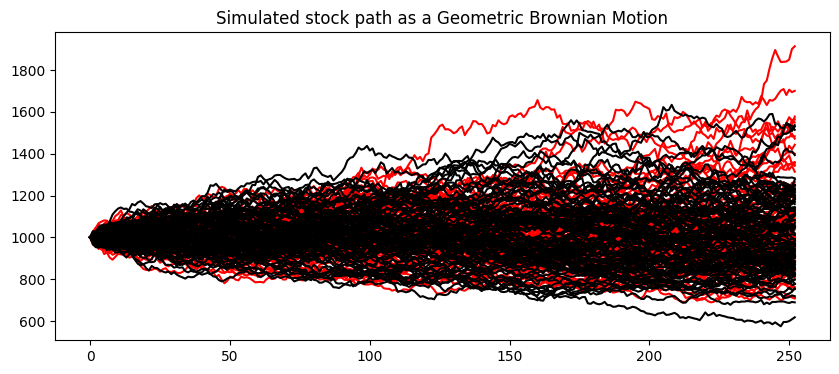

We are 99.0% confident that the losses for the hedged portfolio won't go above 284.95 and the losses for the unhedged portfolio won't go above 311.32.
Hedging is beneficial.


In [2]:
def GBM_paths(S0: np.ndarray, sigma: np.ndarray, t, r, mu, n_sims, n_steps, rho: np.ndarray):
  noise = np.random.multivariate_normal(mean = np.zeros(len(S0)), cov = Correlation_matrix, size = (n_sims, n_steps))
  # For two variables use: noise_B = rho * noise_A + np.sqrt(1 - rho**2) * noise_temp
  # Once can also use Cholesky decompostion for converting uncorrelated data to correlated (especially when it is non-normal)

  dt = t/n_steps
  log_returns = (np.array([mu]*len(S0)) + np.array([r]*len(S0)) - .5*sigma**2)*dt + np.sqrt(dt)*((sigma*(noise)))
  exponent = np.cumsum(log_returns, axis = 1) # this is still an array that adds along time axis

  paths = S0*np.exp(exponent)
  portfolio = np.sum(paths, axis = 2) # summing across stocks
  paths_from_start = np.insert(portfolio, 0, np.sum(S0), axis = 1)

  return paths_from_start

# Execution

Initial_amount = np.array([300, 200, 500]) # Initial_price * Initial_quantity
Correlation_matrix = np.array([[1, .2, -.36], [.2, 1, -.4], [-.36, -.4, 1]])
if not np.array_equal(Correlation_matrix, Correlation_matrix.T):
  print("Error: Correlation matrix is not symmetric")
eigenvalues = np.linalg.eigvals(Correlation_matrix)
if np.any(np.array(eigenvalues) < 0):
  print("Error: Correlation matrix is not positive semidefinite")

rho_unhedged = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
sigma = np.array([.456, .456, .339])

stock_paths_hedged = GBM_paths(Initial_amount,sigma,t,r,mu,n_sims,n_steps, Correlation_matrix)
stock_paths_unhedged = GBM_paths(Initial_amount,sigma,t,r,mu,n_sims,n_steps, rho_unhedged)

final_value_hedged = np.zeros(n_sims)
losses_hedged = np.zeros(n_sims)
final_value_unhedged = np.zeros(n_sims)
losses_unhedged = np.zeros(n_sims)

for i in range(n_sims):
  final_value_hedged[i] = stock_paths_hedged[i][-1]
  losses_hedged[i] = max(0, np.sum(Initial_amount) - final_value_hedged[i])
  final_value_unhedged[i] = stock_paths_unhedged[i][-1]
  losses_unhedged[i] = max(0, np.sum(Initial_amount) - final_value_unhedged[i])

plt.figure(figsize = (10,4))

for path_hedged in stock_paths_hedged:
    plt.plot(path_hedged, color = 'red')
for path_unhedged in stock_paths_unhedged:
    plt.plot(path_unhedged, color = 'black')

plt.title('Simulated stock path as a Geometric Brownian Motion')
plt.show()

print(f"We are {100*alpha}% confident that the losses for the hedged portfolio won't go above {np.quantile(losses_hedged, alpha):.2f} and the losses for the unhedged portfolio won't go above {np.quantile(losses_unhedged, alpha):.2f}.")
if np.quantile(losses_hedged, alpha) < np.quantile(losses_unhedged, alpha):
  print("Hedging is beneficial.")
else:
  print("Hedging is not beneficial.")

---

## 2. Black–Scholes Model and Implied Volatility

### 2.1 The Black–Scholes Formula

Under the **Black–Scholes assumptions** (constant volatility, continuous trading, no dividends, log-normal asset prices), the price of a **European call option** with strike $K$ and time-to-expiry $T$ is:

$$C_{\text{BS}}(S_0, K, \sigma, T, r) = S_0\,\Phi(d_1) - K\,e^{-rT}\,\Phi(d_2)$$

where $\Phi$ is the standard normal CDF and:

$$d_1 = \frac{\ln(S_0/K) + \left(r + \tfrac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

The corresponding **European put** price follows from **put–call parity**:

$$P = C - S_0 + K\,e^{-rT}$$

### 2.2 The Greeks

The **Delta** of a call — the sensitivity of the option price to the underlying — is:

$$\Delta_{\text{call}} = \frac{\partial C}{\partial S_0} = \Phi(d_1)$$

Other key Greeks include **Gamma** $\Gamma = \partial^2 C/\partial S_0^2$, **Vega** $\mathcal{V} = \partial C/\partial \sigma$, and **Theta** $\Theta = \partial C/\partial t$.

### 2.3 Implied Volatility

The Black–Scholes formula is invertible in $\sigma$: given a market price $C_{\text{mkt}}$, the **implied volatility** $\hat{\sigma}$ is the unique solution to:

$$C_{\text{BS}}(S_0, K, \hat{\sigma}, T, r) = C_{\text{mkt}}$$

Since no closed-form inverse exists, $\hat{\sigma}$ is found numerically. The **Brent method** (`brentq`) is a robust bracket-and-interpolate root-finding algorithm that guarantees convergence on $[\sigma_{\min}, \sigma_{\max}]$ where the Black–Scholes price brackets the market price.

In [3]:
def bs_call(S0, K, sigma, t, r):
    '''
    Black-Scholes Call Option formula

    Inputs:
    S0 (float): Stock price at time 0
    K (float): Strike Price
    sigma: Yearly volatility
    t: Time to expiration (years)
    r: Risk-free Interest rate


    Return:
    Black-Scholes value of call option (float)
    '''

    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    call_value = S0*norm.cdf(d1) - K*np.exp(-r*t)*norm.cdf(d2)

    return call_value

def implied_volatility_call(market_price, S0, K, t, r, sigma_bounds=(1e-6, 2)):
  def objective(sigma):
        return bs_call(S0, K, sigma, t, r) - market_price

  try:
        return brentq(objective, *sigma_bounds)
  except ValueError:
        return np.nan

---

## 3. Heston Stochastic Volatility Model — Path Simulation

### 3.1 The Heston Model

The **Heston (1993) model** relaxes the constant-volatility assumption of Black–Scholes by letting variance $v_t$ follow a mean-reverting stochastic process. Under the risk-neutral measure $\mathbb{Q}$:

$$dS_t = (\mu + r)\,S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^S$$

$$dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v$$

with correlation $\langle dW_t^S,\, dW_t^v\rangle = \rho\,dt$.

**Parameters:**

| Symbol | Name | Typical range |
|--------|------|---------------|
| $\kappa$ | Rate of mean reversion | $1$ to $5$ |
| $\theta$ | Long-run (asymptotic) variance | $(0, \infty)$ |
| $\xi$ | Volatility of volatility (vol-of-vol) | $0.2$ to $1$ |
| $\rho$ | Stock–variance correlation | $-0.9$ to $-0.2$ |
| $v_0$ | Initial variance | $(0, \infty)$ |

### 3.2 The Feller Condition

The variance process $v_t$ is the **Cox–Ingersoll–Ross (CIR)** process. It remains strictly positive when the **Feller condition** holds:

$$2\kappa\theta > \xi^2$$

If violated, the variance can hit zero. In numerical implementations the variance is floored at zero: $v_t \leftarrow \max(v_t, 0)$.

### 3.3 Euler–Maruyama Discretisation

With step $\Delta t = T/N$:

$$v_{i+1} = v_i + \kappa(\theta - v_i)\Delta t + \xi\sqrt{v_i\,\Delta t}\,Z_{1,i}, \qquad v_{i+1} \leftarrow \max(v_{i+1}, 0)$$

$$\ln S_{i+1} = \ln S_i + \left(\mu + r - \frac{v_i}{2}\right)\Delta t + \sqrt{v_i\,\Delta t}\,Z_{2,i}$$

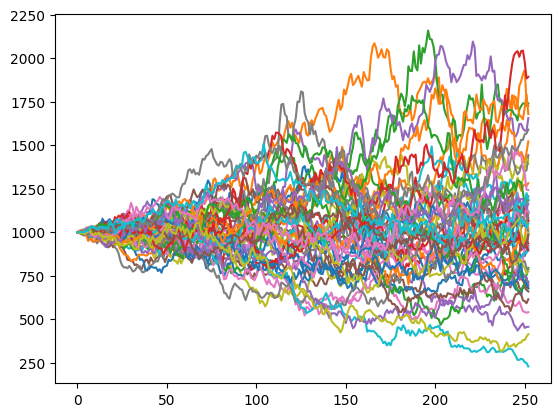

In [4]:
def heston_paths(S0, v0, r, t, rho, kappa, theta, xi, mu, n_sims, n_steps):
    """
    Heston stock path simulation

    Parameters:
    - S0 (float): Initial stock price
    - v0 (float): Initial variance
    - r (float): Risk-free interest rate
    - t (float): Time-to-expiration (in years)
    - kappa (float): Rate of mean reversion of variance (1 to 5)
    - theta (float): Long-run variance
    - xi (float): Volatility of volatility (.2 to 1)
    - rho (float): Correlation between Brownian motions (-.9 to -.2)
    - n_sims (int): Number of simulated paths
    - n_steps (int): Number of steps in each simulated path

    Returns:
    - np array of simulated stock paths
    """
    dt = t/n_steps
    times = np.linspace(0,t, n_steps + 1)

    #noise in random processes with correlation rho

    noise1 = np.random.normal(size = (n_sims,n_steps))
    noise_temp = np.random.normal(size = (n_sims,n_steps))
    noise2 = rho*noise1 + np.sqrt(1-rho**2)*noise_temp #noise1 and noise2 both standard normal, but have correlation rho
    vols = np.zeros((n_sims,n_steps))
    vols[:,0] = v0

    for i in range(1, n_steps):
        vols[:,i] = vols[:,i-1] + kappa*(theta - vols[:,i-1])*dt + xi*np.sqrt(vols[:,i-1]*dt)*noise1[:,i-1]
        vols[:,i] = np.maximum(vols[:,i], 0)

    log_returns = (mu + r - vols/2)*dt + np.sqrt(vols*dt)*noise2
    exponent = np.cumsum(log_returns, axis = 1)
    paths = S0*np.exp(exponent)
    paths = np.insert(paths, 0, S0, axis = 1)

    return paths

n_sims = 50

paths = heston_paths(S0, v0, r, t, rho, kappa, theta, xi, mu, n_sims, n_steps)

for path in paths:
    plt.plot(path)

plt.show()

---

## 4. Heston Option Pricing via Characteristic Functions

### 4.1 Semi-Analytic Pricing Formula

Heston (1993) derived a **semi-closed-form** option pricing formula using the **characteristic function** of $\ln S_T$. The call price is:

$$C = S_0\,P_1 - K\,e^{-rT}\,P_2$$

where $P_1$ and $P_2$ are risk-adjusted probabilities of finishing in the money, computed via **Fourier inversion** of the characteristic function $f(\phi; \cdot)$:

$$P_j = \frac{1}{2} + \frac{1}{\pi}\int_0^{\infty} \operatorname{Re}\!\left[\frac{e^{-i\phi\ln K}\,f_j(\phi)}{i\phi}\right]d\phi, \qquad j = 1, 2$$

### 4.2 The Heston Characteristic Function

The characteristic function $f_j(\phi)$ for the Heston model has the exponential-affine form:

$$f_j(\phi) = \exp\!\left(C_j(\phi) + D_j(\phi)\,v_0 + i\phi\ln\frac{S_0}{K}\right)$$

with:

$$d_j = \sqrt{(\rho\,\xi\,\phi\,i - b_j)^2 - \xi^2(2u_j\,\phi\,i - \phi^2)}$$

$$g_j = \frac{b_j - \rho\,\xi\,\phi\,i + d_j}{b_j - \rho\,\xi\,\phi\,i - d_j}$$

$$C_j(\phi) = r\,\phi\,i\,T + \frac{\kappa\theta}{\xi^2}\left[(b_j - \rho\,\xi\,\phi\,i + d_j)T - 2\ln\frac{1 - g_j\,e^{d_j T}}{1-g_j}\right]$$

$$D_j(\phi) = \frac{b_j - \rho\,\xi\,\phi\,i + d_j}{\xi^2}\cdot\frac{1 - e^{d_j T}}{1 - g_j\,e^{d_j T}}$$

where $u_1 = \tfrac{1}{2}$, $u_2 = -\tfrac{1}{2}$, $b_1 = \kappa - \rho\xi$, $b_2 = \kappa$.

### 4.3 Put–Call Parity

The **put–call parity** relation holds model-independently under no-arbitrage:

$$C - P = S_0 - K\,e^{-rT}$$

which gives the Heston put price directly from the call:

$$P = C - S_0 + K\,e^{-rT}$$

### 4.4 Heston Delta

The **delta** of a Heston call option is:

$$\Delta_{\text{Heston}} = \frac{\partial C}{\partial S_0} = P_1 = \frac{1}{2} + \frac{1}{\pi}\int_0^{\infty}\operatorname{Re}\!\left[\frac{e^{-i\phi\ln K}\,f_1(\phi)}{i\phi}\right]d\phi$$

In [5]:
def heston_option(S0, K, v0, r, t, kappa, theta, xi, rho, option_type):
    """
    Price of a call option under Heston model

    Parameters:
    - S0 (float): Initial stock price
    - K (float): Strike Price
    - v0 (float): Initial variance
    - r (float): Risk-free interest rate
    - t (float): Time-to-expiration (in years)
    - kappa (float): Rate of mean reversion of variance (1 to 5)
    - theta (float): Long-run variance
    - xi (float): Volatility of volatility (.2 to 1)
    - rho (float): Correlation between Brownian motions (-.9 to -.2)
    - option_type (string): 'call' for call and 'put' for put

    Returns:
    - price (float): Option price
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)

        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    P1 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    P2 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 2), 0, 100)[0]
    call_price = S0 * P1 - K * np.exp(-r * t) * P2
    put_price = call_price - S0 + K * np.exp(-r * t) # via put-call parity

    if option_type == 'call':
        return call_price

    if option_type == 'put':
        return put_price

def heston_call_delta(S0, K, v0, r, t, kappa, theta, xi, rho):
    """
    Delta of a call option under Heston model

    Parameters:
    - S0 (float): Initial stock price
    - K (float): Strike Price
    - v0 (float): Initial variance
    - r (float): Risk-free interest rate
    - t (float): Time-to-expiration (in years)
    - kappa (float): Rate of mean reversion of variance (1 to 5)
    - theta (float): Long-run variance
    - xi (float): Volatility of volatility (.2 to 1)
    - rho (float): Correlation between Brownian motions (-.9 to -.2)

    Returns:
    - delta (float): Call option delta
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)

        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    delta = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    return delta

---

## 5. Real Options Data and the Volatility Smile

### Why the Volatility Smile Matters

If Black–Scholes were literally true, the implied volatility $\hat{\sigma}(K, T)$ computed from market prices would be **constant** across strikes $K$ and maturities $T$. In practice, plotting $\hat{\sigma}$ against $K$ reveals a pronounced **volatility smile** or **volatility skew**:

- **Smile**: implied vol is higher for deep in-the-money (ITM) and out-of-the-money (OTM) options, lowest at-the-money (ATM). Common in FX markets.
- **Skew (smirk)**: implied vol decreases monotonically with strike. Characteristic of equity markets — OTM puts are expensive due to crash risk and **negative $\rho$** (leverage effect).

Formally, the implied volatility surface is the map:

$$(K, T) \mapsto \hat{\sigma}(K, T) = C_{\text{BS}}^{-1}(C_{\text{mkt}}(K, T))$$

/tmp/ipykernel_18730/1066646059.py:42: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock_symbol, period = '1d', interval = '1m')
[*********************100%***********************]  1 of 1 completed


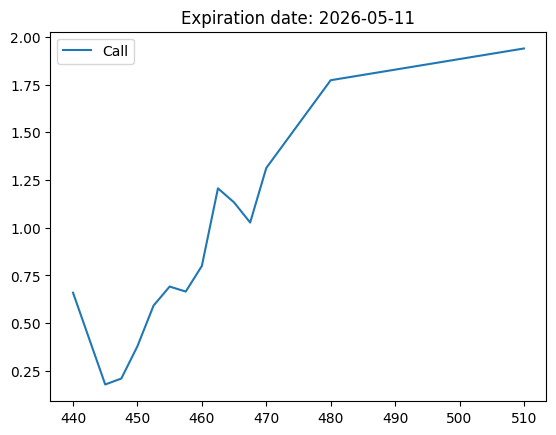

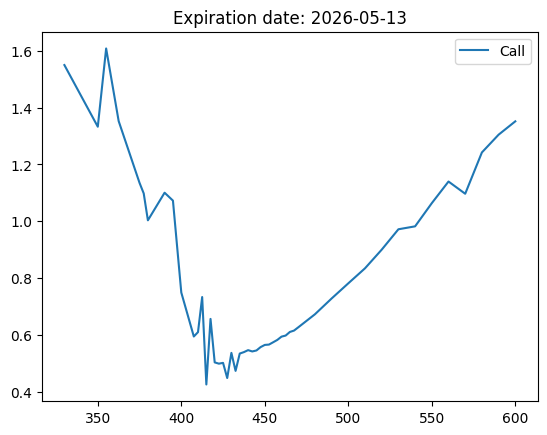

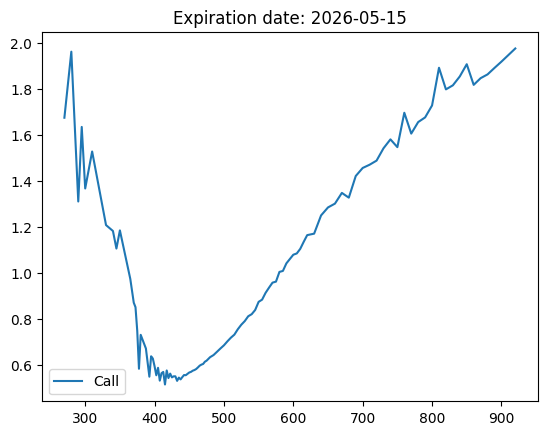

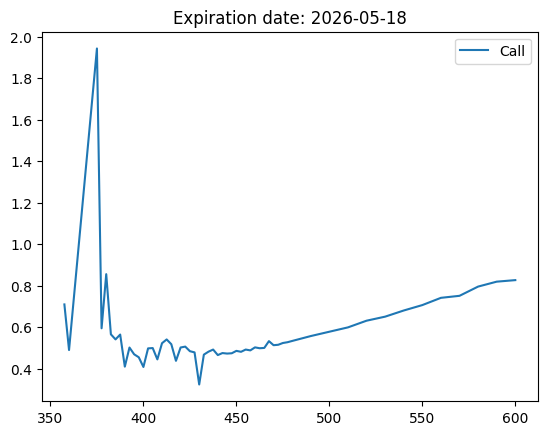

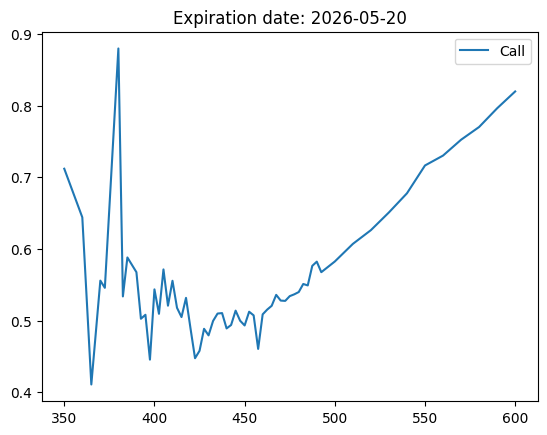

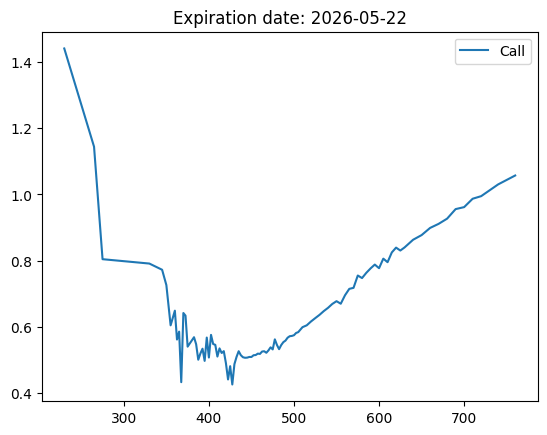

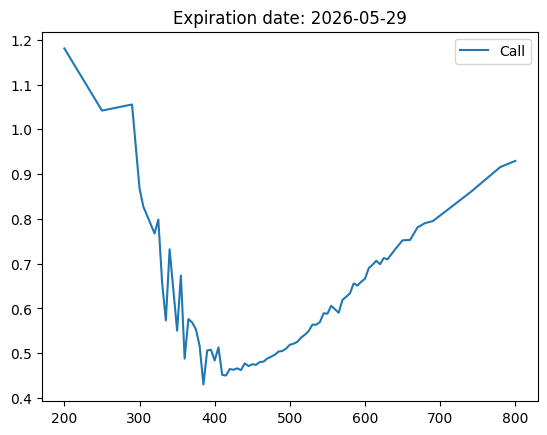

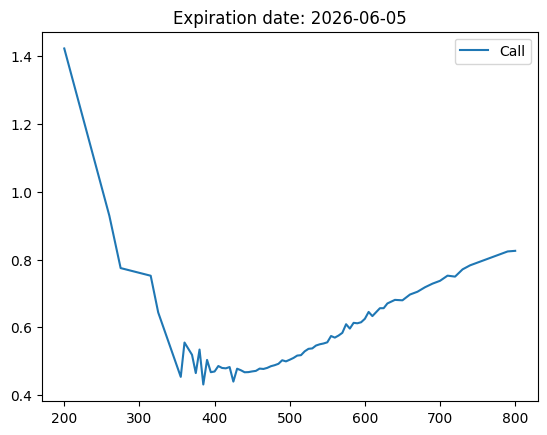

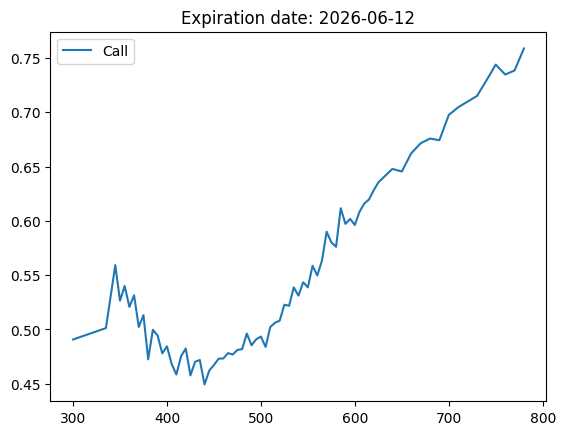

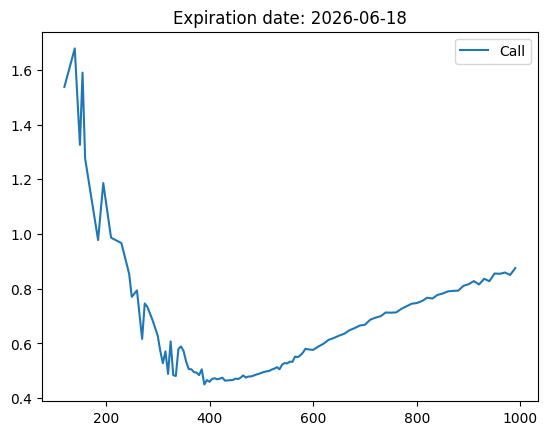

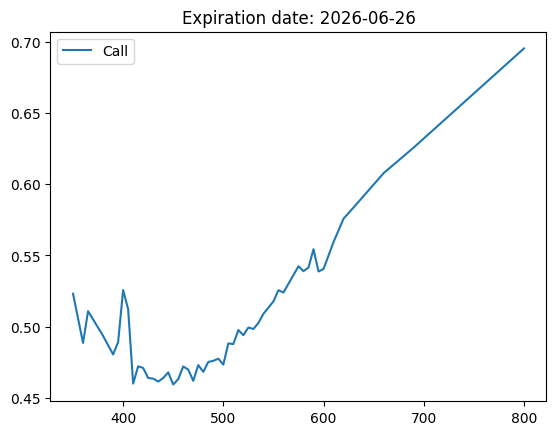

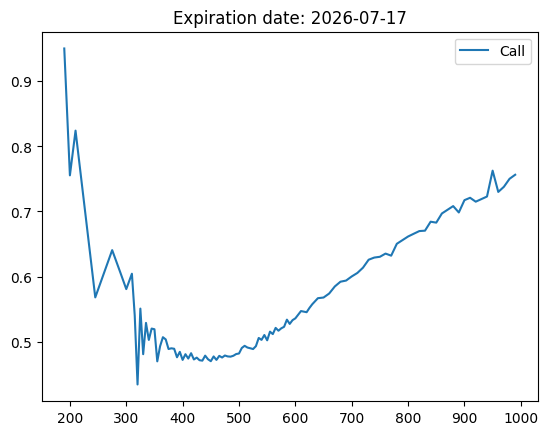

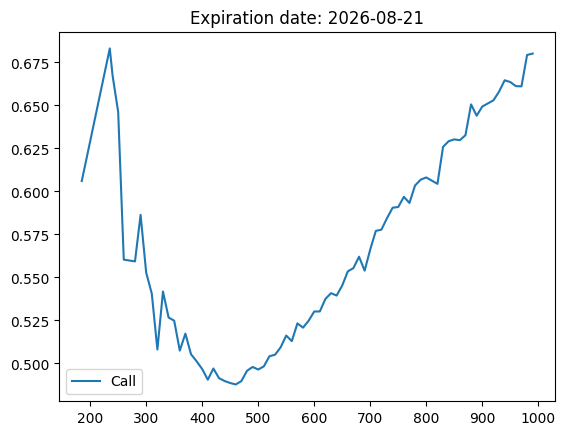

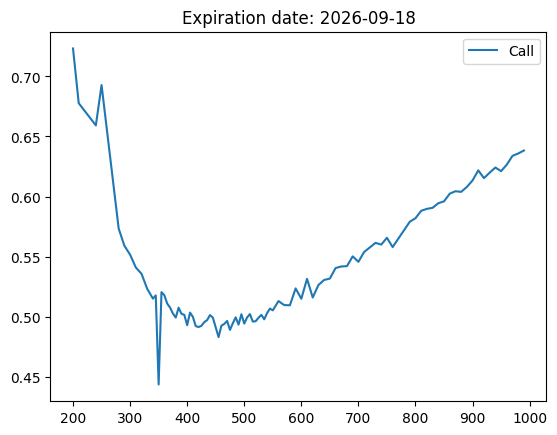

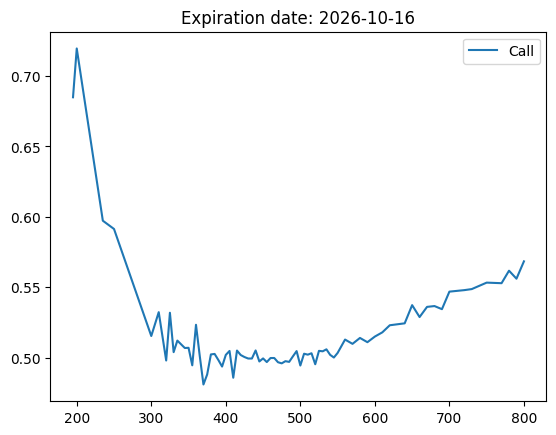

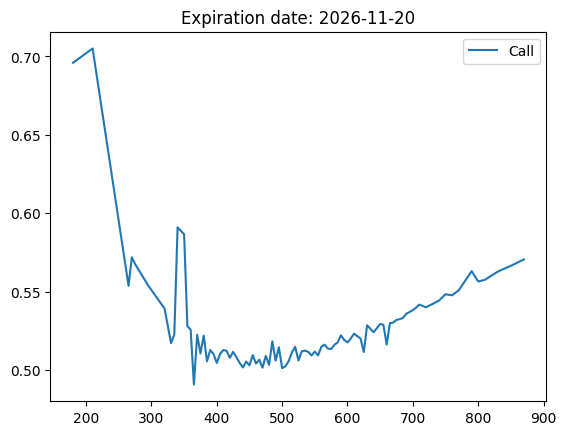

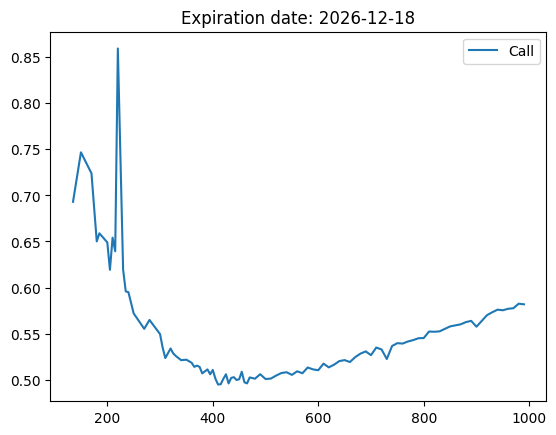

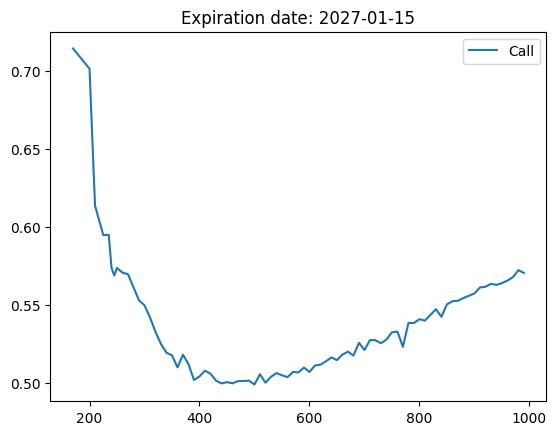

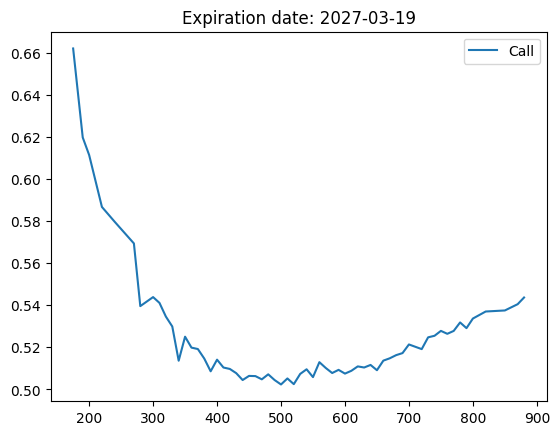

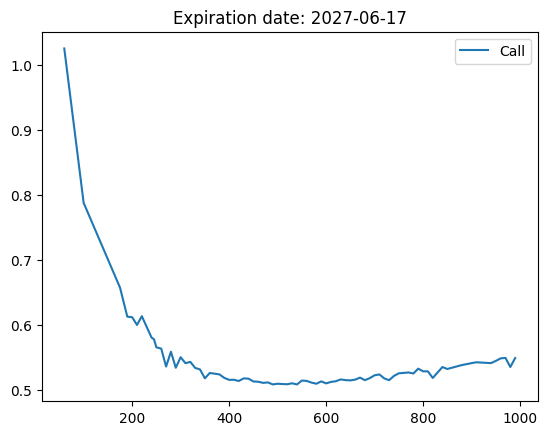

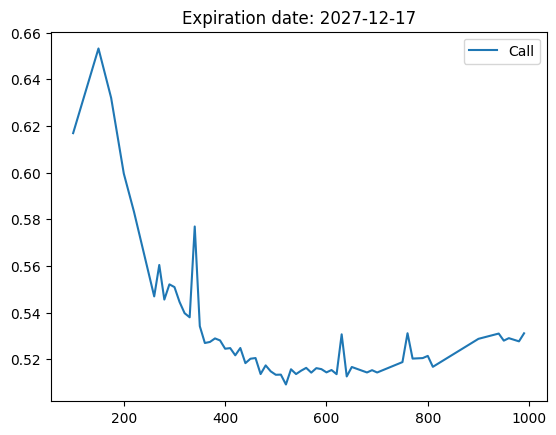

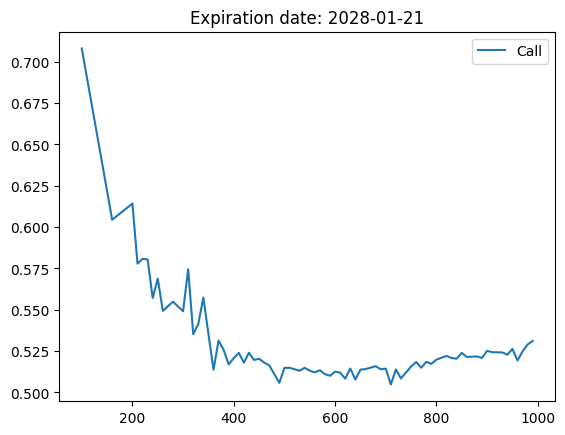

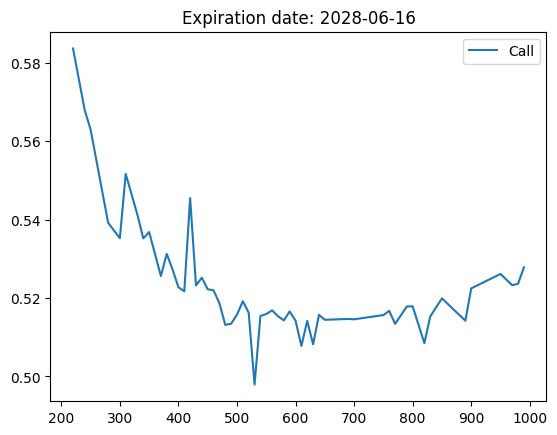

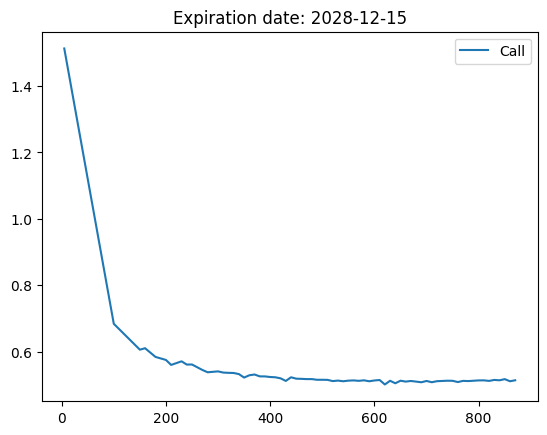

In [6]:
option_data = []

# Functions for option data obtained through y-finance
def find_tte_yf_options(expiration_date,last_trade_date):
    '''returns time measured in years as a float between two dates

    Inputs:
    expiration_date (str): 'YYYY-MM-DD'
    last_trade_date (pandas._libs.tslibs.timestamps.Timestamp)

    Returns:
    Float of time to expiration in years
    '''
    tte = (datetime.datetime.strptime(expiration_date+'-21-30', "%Y-%m-%d-%H-%M").replace(tzinfo=tzutc()) - last_trade_date).total_seconds()/(60*60*24*365)

    return tte


def yf_find_approx_spot(stock_data, last_trade_date):
    """
    Finds approximate spot price at the time of last trade.
    The spot price is approximate since yfinance does not provide 1-second data, only minute-by-minute.

    Parameters:
    stock_data (pd.Series or pd.DataFrame): stock prices with DatetimeIndex
    last_trade_date (pd.Timestamp): timestamp of last trade of option contract

    Returns:
    float: approximate spot price, or NaN if unavailable
    """
    # Round timestamp to the minute (zero out seconds)
    ts = last_trade_date.replace(second=0)

    try:
        return stock_data.loc[ts].iloc[0]
    except KeyError:
        return float('nan')

# Execution

ticker = yf.Ticker(stock_symbol)
stock_data = yf.download(stock_symbol, period = '1d', interval = '1m')
expirations = ticker.options

for date in expirations:
    chain = ticker.option_chain(date)

    # Add expiration and label
    calls = chain.calls.copy()
    calls['expiration'] = date
    calls['option_type'] = 'call'
    option_data.append(calls)

# Combine all into one DataFrame and delete implied volatility column since we'll recalculate.
options_data = pd.concat(option_data, ignore_index=True)
options_data = options_data.drop(columns=['impliedVolatility'])

# Delete any options that were traded in the interval of historical stock values obtained
start_date = stock_data.index[0]
options_data = options_data[options_data['lastTradeDate']>=start_date]

# Insert column of time to expiration in years of the option contract measured from time of last trade
options_data['time_to_expiration'] = options_data.apply(
lambda row: find_tte_yf_options(expiration_date = row['expiration'],
                               last_trade_date = row['lastTradeDate']),
    axis = 1
)

# Add in column of the spot price of stock when the option trade occured.
options_data['spot_price'] = options_data.apply(
    lambda row: yf_find_approx_spot(stock_data['Close'], row['lastTradeDate']),
    axis=1
)

# Create data frames that keeps relevant information for calls
options_data = options_data[['strike', 'lastPrice', 'lastTradeDate',\
                             'expiration', 'option_type','time_to_expiration', 'spot_price']]
options_data_calls = options_data[(options_data['option_type'] == 'call')].copy()

# Add implied volatility column in calls data frame
options_data_calls['implied_volatility'] = options_data_calls.apply(
    lambda row: implied_volatility_call(
        market_price=row['lastPrice'],
        S0 = row['spot_price'],
        K=row['strike'],
        t=row['time_to_expiration'],
        r=r
    ),
    axis=1
)

# Remove rows with undefined values
options_data_calls = options_data_calls.dropna()

# Data visualization of option volatility smiles
for date in expirations:

    call_data = options_data_calls[options_data_calls['expiration'] == date]
    call_strikes = call_data['strike']
    call_imp_vol = call_data['implied_volatility']

    plt.plot(call_strikes.values, call_imp_vol.values, label = 'Call')

    plt.title(f'Expiration date: {date}')
    plt.legend()
    plt.show()
    print('\n')

---

## 6. Heston Model Calibration

### 6.1 The Calibration Problem

**Calibration** is the process of finding Heston parameters $\boldsymbol{\psi} = (\kappa, v_0, \xi, \rho, \theta)$ that best fit observed market option prices $\left\{C_{\text{mkt}}^{(i)}\right\}_{i=1}^N$. The standard approach is **least-squares minimisation** of the **mean squared error (MSE)**

### 6.2 Practical Notes

- Only expiry dates with well-behaved volatility smiles should be included in the calibration dataset, as noisy or illiquid option data degrades parameter estimates.
- A random sub-sample of the data (`sample(100)`) is used for computational efficiency; in production, all liquid strikes and maturities should be included.

In [7]:
dates = ['2026-08-21', '2027-01-15','2027-06-17', '2028-01-21'] # Insert dates that have reasonable volatility smiles

options_data_calls_cleaned = options_data_calls[options_data_calls['expiration'].isin(dates)]

def objective(params, data, r):
    kappa, v0, xi, rho, theta = params

    error = 0
    for _, row in data.iterrows():
        model_price = heston_option(
            S0=row['spot_price'],
            K=row['strike'],
            v0=v0,
            r=r,
            t=row['time_to_expiration'],
            kappa=kappa,
            theta=theta,
            xi=xi,
            rho=rho,
            option_type = row['option_type']
        )
        market_price = row['lastPrice']
        error += (model_price - market_price) ** 2

    return error / len(data)

options_data_cleaned = pd.concat(
    [options_data_calls_cleaned],
    ignore_index=True)

initial_guess = [3, .4**2, .6, -.6,.4**2]  #kappa, v0, xi, rho, theta
bounds = [(.01, 8), (.1**2, .9**2), (.01, 2), (-1,-0.01), (.1**2, .9**2)]

data_sample = options_data_calls_cleaned.sample(100)

result = minimize(
    objective,
    initial_guess,
    args=(data_sample, r),
    bounds=bounds,
    method='L-BFGS-B',
    options={
        'disp': True,
        'maxiter': 20,
        'ftol': 1e-4,
        'gtol': 1e-4
    }
)
kappa, v0, xi, rho, theta = result.x

/tmp/ipykernel_18730/148511118.py:36: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


---

## 7. Delta Hedging Backtest under the Heston Model

### 7.1 Delta Hedging

**Delta hedging** is a dynamic strategy that eliminates first-order exposure to movements in the underlying. A dealer who sells a call option at $t=0$ hedges by holding $\Delta_t$ shares of the underlying at each time step, where:

$$\Delta_t = \frac{\partial C}{\partial S_t}$$

Under the Heston model, $\Delta_t = P_1(S_t, v_t, \tau_t)$ as derived in Section 4.4.

### 7.2 Hedging P&L

The **discounted profit** of the delta hedge over one discrete time step $[t_i, t_{i+1}]$ is:

$$\pi_i = \Delta_i\left(S_{i+1} - S_i\,e^{r\Delta t}\right)e^{-r\,t_{i+1}}$$

This represents the gain from holding $\Delta_i$ shares, net of financing costs (borrowing at rate $r$), discounted back to $t=0$.

### 7.3 Total Hedging Profit

The total discounted P&L of the hedging strategy over the life of the option is:

$$\Pi_{\text{hedge}} = \sum_{i=0}^{N-1} \pi_i$$

The discounted call payout at expiry $T$ is:

$$\Pi_{\text{call}} = e^{-rT}\max(S_T - K,\, 0)$$

The **total profit** of the position (short call + delta hedge) is:

$$\Pi_{\text{total}} = \Pi_{\text{call}} + \Pi_{\text{hedge}}$$

In a **perfect hedge** under continuous trading with the correct model, $\Pi_{\text{total}} = 0$. Deviations reflect **discrete rebalancing error**, **model misspecification**, and **transaction costs**.

In [8]:
t = 2

stock_data = yf.download(stock_symbol, period = '2y', interval = '1d')
stock_path = np.array(stock_data['Close'][stock_symbol].values[-n_steps-1:])
rol_sigmas = (np.log((stock_data['Close'][stock_symbol].pct_change()+1)).rolling(window = 21).std()*np.sqrt(252))[-n_steps-1:]
rol_vols = rol_sigmas**2
K = stock_path[0] # ATM Call just to begin with.

dt = t/n_steps
deltas = np.zeros(n_steps)
times = np.linspace(0,t, n_steps + 1)

for i in range(n_steps):
    deltas[i] = heston_call_delta(stock_path[i], K, rol_vols.iloc[i], r, (t-times)[i], kappa, theta, xi, rho)

stock_profits = (stock_path[1:n_steps+1] - stock_path[0:n_steps]*np.exp(r*dt))*np.exp(-r*times[1:n_steps+1])*deltas
total_stock_profit = np.sum(stock_profits)
call_payout = np.maximum(stock_path[-1] - K, 0)*np.exp(-r*t)
call_profit_hedged = call_payout + total_stock_profit

print(f"The call payout is ${call_payout:.2f} and the stock profit is ${total_stock_profit:.2f}. So, the total profit of the hedging strategy is ${call_profit_hedged:.2f}.")

/tmp/ipykernel_18730/4237080522.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock_symbol, period = '2y', interval = '1d')
[*********************100%***********************]  1 of 1 completed


The call payout is $147.86 and the stock profit is $84.72. So, the total profit of the hedging strategy is $232.58.


**Things that were studied during the boot camp but not mentioned here**
- Put options and both legs in calibration for improved robustness.
- Compare Heston hedging with Black–Scholes delta hedging on the same path.
- Explore models that consider discontinuous price movements (e.g., Merton Jump Diffusion model).

**Extensions to explore:**
- Explore **rough volatility models** (e.g. rough Bergomi) for more realistic vol-of-vol dynamics.
- Explore other greeks, compare greeks of various models
- Explore binomial and trinomial tree option pricing to price American and other exotic options